This notebook closes the Customer Churn Analytics project. Building on the final model selected in `03_Model_Optimization` — XGBoost (`max_depth=5`, `learning_rate=0.1`,`n_estimators=70`, `scale_pos_weight` for class imbalance, decision threshold=0.45.)
This notebook translates model results into actionable business insights.

## Step 1: Model Comparison

A summary table recapping the full optimization journey (baseline → class_weight → SMOTE → GridSearchCV → threshold tuning) for both Logistic Regression and XGBoost, showing why XGBoost at threshold=0.45 was retained as the final model rather thanpresenting only the final result in isolation.

## Step 2: Feature Importance Analysis

Identifying which customer attributes drive the model's churn predictions, using two complementary approaches:
- **Native XGBoost importance** (`feature_importances_`) a quick overview of which  features the model relies on most
- **SHAP values** a more rigorous view that also shows the *direction* of each feature's effect (does it push predictions toward Churn or No Churn)

## Step 3: Cross-Checking with Exploratory Data Analysis

Comparing the model's top features against the univariate and bivariate patterns already observed in `01_EDA` (e.g. churn rate by contract type, tenure, payment method). Agreement between descriptive analysis and model-driven importance strengthens confidence that these variables reflect genuine churn drivers.

## Step 4: Individual Customer Prediction Example

A concrete simulation: predicting churn probability for a hypothetical customer profile (e.g. month-to-month contract, low tenure), and comparing how that probability changes when varying a single attribute (such as contract type) whileholding everything else constant, illustrating the model's practical use case.

## Step 5: Business Recommendations for Customer Retention

Translating the confirmed churn drivers into concrete, actionable recommendations for the retention team,which customer segments to prioritize, and what interventions are most likely to reduce churn risk based on the patterns identified above.

## Conclusion

A final summary tying together the project's key findings: model performance, the main churn drivers identified, and the business value of the retention strategy proposed.

In [5]:
import pandas as pd
comparison_data = [
    # --- Logistic Regression ---
    {"Model": "Logistic Regression", "Stage": "Baseline",
     "Recall": 0.559, "Precision": 0.657, "F1": 0.604, "Accuracy": 0.806, "ROC-AUC": 0.842},
    {"Model": "Logistic Regression", "Stage": "class_weight",
     "Recall": 0.783, "Precision": 0.504, "F1": 0.614, "Accuracy": 0.738, "ROC-AUC": 0.842},
    {"Model": "Logistic Regression", "Stage": "SMOTE",
     "Recall": 0.794, "Precision": 0.503, "F1": 0.616, "Accuracy": 0.737, "ROC-AUC": 0.840},
    {"Model": "Logistic Regression", "Stage": "GridSearchCV (final, C=0.1)",
     "Recall": 0.786, "Precision": 0.508, "F1": 0.617, "Accuracy": 0.741, "ROC-AUC": 0.841},

    # --- XGBoost ---
    {"Model": "XGBoost", "Stage": "Baseline",
     "Recall": 0.519, "Precision": 0.590, "F1": 0.552, "Accuracy": 0.776, "ROC-AUC": 0.820},
    {"Model": "XGBoost", "Stage": "class_weight",
     "Recall": 0.668, "Precision": 0.556, "F1": 0.607, "Accuracy": 0.770, "ROC-AUC": 0.820},
    {"Model": "XGBoost", "Stage": "SMOTE",
     "Recall": 0.578, "Precision": 0.579, "F1": 0.578, "Accuracy": 0.776, "ROC-AUC": 0.821},
    {"Model": "XGBoost", "Stage": "GridSearchCV (n_estimators=70)",
     "Recall": 0.781, "Precision": 0.524, "F1": 0.627, "Accuracy": 0.754, "ROC-AUC": 0.839},
    {"Model": "XGBoost", "Stage": "Threshold tuning (0.45) — FINAL MODEL",
     "Recall": 0.810, "Precision": 0.506, "F1": 0.623, "Accuracy": 0.740, "ROC-AUC": 0.839},
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df.style.format({
    "Recall": "{:.3f}", "Precision": "{:.3f}", "F1": "{:.3f}",
    "Accuracy": "{:.3f}", "ROC-AUC": "{:.3f}"
})

,Model,Stage,Recall,Precision,F1,Accuracy,ROC-AUC
0,Logistic Regression,Baseline,0.559,0.657,0.604,0.806,0.842
1,Logistic Regression,class_weight,0.783,0.504,0.614,0.738,0.842
2,Logistic Regression,SMOTE,0.794,0.503,0.616,0.737,0.840
3,Logistic Regression,"GridSearchCV (final, C=0.1)",0.786,0.508,0.617,0.741,0.841
4,XGBoost,Baseline,0.519,0.590,0.552,0.776,0.820
5,XGBoost,class_weight,0.668,0.556,0.607,0.770,0.820
6,XGBoost,SMOTE,0.578,0.579,0.578,0.776,0.821
7,XGBoost,GridSearchCV (n_estimators=70),0.781,0.524,0.627,0.754,0.839
8,XGBoost,Threshold tuning (0.45) — FINAL MODEL,0.810,0.506,0.623,0.740,0.839


### Interpretation — Full Optimization

The table above summarizes every stage of optimization for both models. Two distinct patterns emerge:

**Logistic Regression** improved steadily from baseline to `class_weight` (Recall 0.559 → 0.783), but plateaued from that point onward — SMOTE and GridSearchCV each added only marginal gains (F1 stayed within 0.614–0.617), and ROC-AUC never moved beyond 0.840–0.842. This confirms that, for this model, class weighting captured nearly all of the achievable improvement early on.

**XGBoost** showed a different trajectory: `class_weight` improved Recall substantially, but SMOTE actually *hurt* performance (F1 dropped to 0.578) — a result specific to boosting's sensitivity to synthetic noise, discussed in the corresponding section. GridSearchCV then delivered the largest single gain of the whole process (F1 0.607 → 0.627, ROC-AUC 0.820 → 0.839), and threshold tuning added a final, deliberate shift toward Recall (0.781 → 0.810) at negligible F1 cost.

**Final model retained: XGBoost, threshold=0.45.** Beyond its slightly better F1 and Accuracy compared to the best Logistic Regression configuration, the decisive factor is that XGBoost's ROC-AUC genuinely improved through optimization (0.820 → 0.839), while Logistic Regression's stayed flat throughout — indicating XGBoost's gains reflect real improvements in the model's ability to distinguish churners, not just a relocated decision threshold.

## Step 2: Feature Importance Analysis

Before drawing business conclusions, it is worth understanding wich customer attributes the final XGBoost model actually relies on to predict churn. This differsfrom the exploratory analysis in `01_EDA`, which looked at each variable's association with churn individually or in pairs . Feature importance instead reflects how the model weights each variable **within the full context of all others combined**.

Since the model was trained on preprocessed data (numeric features scaled, categorical features one-hot encoded), the feature names must first be reconstructed to match what the model actually sees,a categorical variable like `Contract` is split by`OneHotEncoder` into several binary columns (e.g. `Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`), each receiving its own importance scorerather than one combined score for the original variable.

In [6]:
import joblib
import pandas as pd

best_xgb_ext = joblib.load("final_xgboost_model.pkl")

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

final_threshold = joblib.load("final_threshold.pkl")

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Model and data loaded successfully.")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Retained threshold: {final_threshold}")

Model and data loaded successfully.
X_train shape: (5634, 19) | X_test shape: (1409, 19)
Retained threshold: 0.45


Top 15 Most Important Features


,feature,importance
36,Contract_Month-to-month,0.520186
16,InternetService_Fiber optic,0.108719
18,OnlineSecurity_No,0.054453
15,InternetService_DSL,0.029976
35,StreamingMovies_Yes,0.027244
38,Contract_Two year,0.024885
27,TechSupport_No,0.021712
37,Contract_One year,0.019466
43,PaymentMethod_Electronic check,0.014107
1,tenure,0.014095


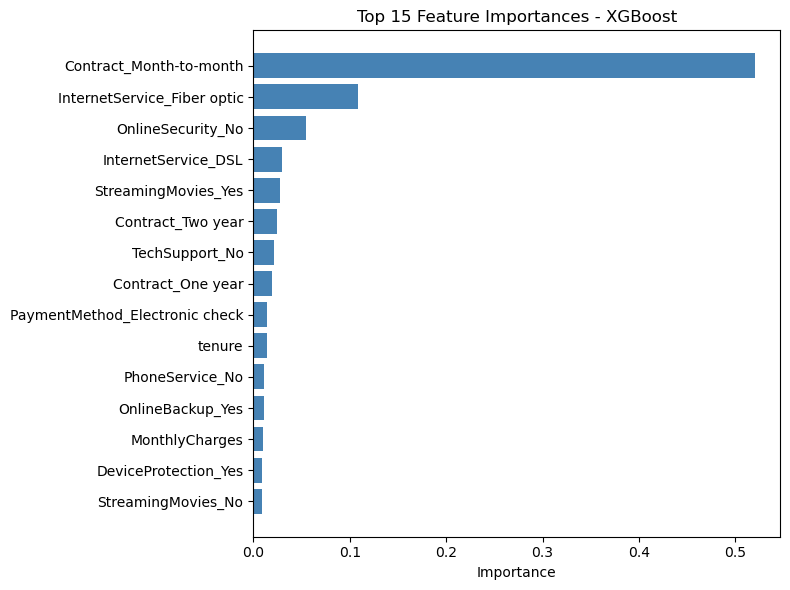

In [7]:
# 
# Step 2: Feature Importance Analysis - Native XGBoost

import matplotlib.pyplot as plt

# Extract feature names after preprocessing (OneHotEncoder expands each categorical column into multiple binary columns)

feature_names = (
    list(numeric_features) +
    list(best_xgb_ext.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_features))
)


# Get importances from the trained model

importances = best_xgb_ext.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 15 Most Important Features")
display(importance_df.head(15))

# Plot

plt.figure(figsize=(8, 6))
top_15 = importance_df.head(15).sort_values(by="importance")
plt.barh(top_15["feature"], top_15["importance"], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

###Step 3: Cross-Checking with Exploratory Data Analysis 

The feature importance results align closely with the bivariate patterns already observed in `01_EDA`.

**Contract type** shows the strongest signal in both analyses: churn rate ranges from 42.7% (Month-to-month) down to 2.8% (Two year) ( ~15x gradient) matching `Contract_Month-to-month` as the single most influential feature (importance=0.520, nearly 5x the second-ranked feature).

**Internet service type** shows the second-strongest signal, but with an important nuance. Churn rate is 41.9% for Fiber optic customers, compared to 19.0% for DSL and 7.4% for customers without internet service ,consistent with `InternetService_Fiber optic` ranking second in feature importance (0.109). However,average `MonthlyCharges` follows the same ordering almost exactly: $91.50 for Fiber optic, $58.10 for DSL, and $21.08 for customers with no internet service  a 57% price gap between Fiber optic and DSL. This strongly suggests that price sensitivity is a major contributing factor behind the Fiber optic churn signal, rather than the technology itself being inherently less satisfying. This distinction matters for the business recommendations that follow: the actionable lever here may be pricing or perceived value, not necessarily service quality.

The consistency between these descriptive statistics and the model's internal feature weighting gives strong confidence that `Contract`, `InternetService`, and pricing are genuine, interconnected churn drivers in this dataset, rather than artifacts of the optimization process.

## Step 4: Individual Customer Prediction Example

Beyond aggregate feature importance, it is useful to see how the model behaves on a concrete, individual case — translating statistical patterns into a practical illustration of how the model would be used in production.

This section simulates a hypothetical customer profile and varies a single attribute at a time , starting with `Contract`(the model's most influential feature)  while holding all other characteristics constant. This isolates the effect of that one variable on the predicted churn probability, complementing the aggregate view from feature importance with a concrete, interpretable example.

In [8]:
# Step 3: Individual Customer Prediction Example
# ------------------------------------------------------------
# Test 1 Vary Contract, holding everything else constant
# ------------------------------------------------------------

# Define a baseline hypothetical customer profile

base_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 255.0
}

new_customer = pd.DataFrame([base_customer])


# Predict using the final model and the retained threshold (0.45)

prob_churn = best_xgb_ext.predict_proba(new_customer)[:, 1][0]
prediction = "Churn" if prob_churn >= final_threshold else "No Churn"

print(f"Predicted churn probability: {prob_churn:.3f}")
print(f"Prediction (threshold={final_threshold}): {prediction}")


# Vary Contract only, holding everything else constant

contracts_to_test = ["Month-to-month", "One year", "Two year"]
results_contract = []

for contract in contracts_to_test:
    test_customer = new_customer.copy()
    test_customer["Contract"] = contract
    prob = best_xgb_ext.predict_proba(test_customer)[:, 1][0]
    results_contract.append({
        "Contract": contract,
        "Churn Probability": round(prob, 3),
        "Prediction": "Churn" if prob >= final_threshold else "No Churn"
    })

results_contract_df = pd.DataFrame(results_contract)
display(results_contract_df)
# ------------------------------------------------------------
#Test 2: Vary OnlineSecurity, holding everything else constant
# ------------------------------------------------------------

security_options = ["No", "Yes"]
results_security = []

for option in security_options:
    test_customer = new_customer.copy()
    test_customer["OnlineSecurity"] = option
    prob = best_xgb_ext.predict_proba(test_customer)[:, 1][0]
    results_security.append({
        "OnlineSecurity": option,
        "Churn Probability": round(prob, 3),
        "Prediction": "Churn" if prob >= final_threshold else "No Churn"
    })

print("Effect of OnlineSecurity")
display(pd.DataFrame(results_security))
# ------------------------------------------------------------
# Test 3: Vary MonthlyCharges, holding everything else constant
# ------------------------------------------------------------
charges_to_test = [30.0, 55.0, 85.0, 110.0]
results_charges = []

for charge in charges_to_test:
    test_customer = new_customer.copy()
    test_customer["MonthlyCharges"] = charge
    prob = best_xgb_ext.predict_proba(test_customer)[:, 1][0]
    results_charges.append({
        "MonthlyCharges": charge,
        "Churn Probability": round(prob, 3),
        "Prediction": "Churn" if prob >= final_threshold else "No Churn"
    })

print("\nEffect of MonthlyCharges")
display(pd.DataFrame(results_charges))


Predicted churn probability: 0.839
Prediction (threshold=0.45): Churn


,Contract,Churn Probability,Prediction
0,Month-to-month,0.839,Churn
1,One year,0.521,Churn
2,Two year,0.103,No Churn


Effect of OnlineSecurity


,OnlineSecurity,Churn Probability,Prediction
0,No,0.839,Churn
1,Yes,0.666,Churn



Effect of MonthlyCharges


,MonthlyCharges,Churn Probability,Prediction
0,30.0,0.661,Churn
1,55.0,0.737,Churn
2,85.0,0.839,Churn
3,110.0,0.689,Churn


### Interpretation — Individual Customer Prediction

For an identical hypothetical customer (Fiber optic internet, 3 months tenure, no security/support add-ons, $85 monthly charges), varying only the contract type changes the predicted churn probability from **0.839 (Month-to-month)** to **0.521 (One year)** to **0.103 (Two year)** ;an 8-fold reduction in risk driven by a single variable, with everything else held constant.

Notably, the model's classification only flips from "Churn" to "No Churn" between One year and Two year contracts (0.521 vs 0.103, both relative to the retained threshold of 0.45)  suggesting that the strongest protective effect of contract length comes specifically from committing to a two-year term, rather than a gradual, linear reduction in risk with contract length.

This concrete example reinforces, at the individual level, what both the exploratory analysis and the aggregate feature importance already showed: contract type is not just statistically associated with churn .It has a large, isolable effect on the model's predicted risk for an otherwise identical customer.

Beyond `Contract`, two more variables were tested in isolation on the same customer profile:

**OnlineSecurity**: switching from "No" to "Yes" reduces churn probability from 0.839to 0.666 a clear, consistent effect, aligned with its ranking as the third most important feature in the model.

**MonthlyCharges**: unlike Contract and OnlineSecurity, this variable shows a **non-monotonic** effect — churn probability rises from 0.661 ($30) to a peak of 0.839 ($85), then falls to 0.689 ($110). This reflects XGBoost's ability to capture non-linear relationships between variables, unlike a linear model such as Logistic Regression. It suggests price sensitivity does not act in isolation, and cautions against summarizing the effect of `MonthlyCharges` with a single directional statement in the business recommendations — unlike Contract and OnlineSecurity, which show clean, interpretable, and consistently directional effects.

## Step 5: Business Recommendations for Customer Retention

Based on the exploratory analysis, feature importance results, and isolated individual-customer prediction tests, four converging pieces of  evidence point to specific, prioritized retention levers.

### 1. Prioritize converting Month-to-month customers to longer contracts

Month-to-month customers churn at 42.7%, compared to 11.3% (One year) and 2.8% (Two year) confirmed as the model's dominant feature (importance=0.520) and shown to reduce individual churn risk 8-fold (0.839 → 0.103) when isolated from all other factors in a controlled test.

**Recommended actions:**
- Target Month-to-month customers with incentivized offers to switch to annual or two-year contracts (e.g. a discount proportional to commitment length).
- Prioritize outreach for Month-to-month customers with low tenure (<6 months), the segment most exposed to both risk factors simultaneously.
- Since the risk drop is much sharper between One year and Two year than between Month-to-month and One year, retention offers should specifically emphasize the two-year commitment rather than treating "any contract" as an equally effective goal.

### 2. Promote OnlineSecurity adoption as a low-cost retention lever

OnlineSecurity ranks third in feature importance, and an isolated test confirms a clear, consistent effect: enabling it reduces predicted churn probability from 0.839 to 0.666 for an otherwise identical customer a substantial drop for a single add-on.

**Recommended actions:**
- Offer OnlineSecurity as a free or heavily discounted add-on for new and at-risk customers, particularly those on Month-to-month contracts with Fiber optic internet.
- Include it by default in retention offers, rather than treating it as a purely optional upsell.

### 3. Address the Fiber optic pricing gap — with caution on broader pricing claims

Fiber optic customers churn at 41.9%, coinciding with a 57% higher average monthly charge compared to DSL ($91.50 vs $58.10). However, an isolated test varying `MonthlyCharges` alone showed a **non-linear** relationship ; churn probability rose from 0.661 ($30) to a peak of 0.839 ($85), then fell to 0.689 ($110)  indicating price is not a simple, uniformly-directional driver across all customers. **This recommendation should therefore remain scoped specifically to the Fiber optic segment**, where the price-churn association is supported by both EDA and feature importance, rather than generalized into a company-wide pricing strategy.

**Recommended actions:**
- Investigate Fiber optic pricing tiers and perceived value specifically, rather than broad price reductions.
- Consider bundling Fiber optic with OnlineSecurity/TechSupport (see recommendation 2) at a reduced combined rate, addressing two confirmed risk factors together.

### 4. Use the model to prioritize retention resources, not replace judgment

With Recall=0.810 and Precision=0.506 at the retained threshold (0.45), the model correctly flags roughly 4 out of 5 actual churners, at the cost of also flagging some loyal customers. Given the established cost asymmetry (a missed churner is more costly than an unnecessary retention offer), this model is best used as a **prioritization tool** — ranking customers by churn risk to focus retention team effort  rather thanas an automated decision system acting without human review.

## Conclusion

This project set out to predict customer churn and identify actionable drivers behind it, using the Telco customer dataset. Four models were compared, optimized through class weighting, SMOTE, hyperparameter tuning, and decision threshold adjustment, and the resulting model was interpreted alongside the exploratory analysis to produce concrete business recommendations.

**Model performance.** XGBoost was selected as the final model over Logistic Regression, Decision Tree, and Random Forest, based on its superior F1-score (0.627) and  more importantly a genuine improvement in ROC-AUC through optimization (0.820 → 0.839), indicating the model's ability to rank customers by risk actually improved, rather than simply shifting where the decision boundary falls. With the retained decision threshold of 0.45, the final model achieves Recall=0.810 and Precision=0.506, correctly identifying roughly 4 out of 5 customers who will churn ,a deliberate trade-off favoring churn detection, justified by the higher business cost of a missed churner compared to an unnecessary retention offer.

**Key churn drivers.** Three independent sources of evidence converged on the same conclusions: bivariate analysis in `01_EDA`, the model's feature importance, and a controlled individual prediction example. Contract type is by far the strongest driver  Month-to-month customers churn at 42.7%, against 2.8% for Two-year contracts, a pattern the model weighs roughly 5 times more heavily than any other feature.
Internet service type is the second strongest signal, though largely intertwined with pricing: Fiber optic customers pay 57% more on average than DSL customers and churn at a correspondingly higher rate, suggesting perceived value for money — not the technology itself — as the more likely underlying driver.

**Business impact.** These findings translate into two concrete, prioritized retention levers: converting Month-to-month customers toward longer commitments (especially two-year contracts, which show the sharpest risk reduction), and reassessing Fiber optic pricing or bundling strategy to address the value perception gap. The model itself is best positioned as a prioritization tool for the retention team — ranking
customers by risk to focus outreach efficiently — rather than a fully automated decision system.

**Limitations and future work.** This analysis is based on a single snapshot of customer data rather than a time-series view of behavior leading up to churn, which limits causal claims associations identified here (e.g. Fiber optic and price) are strongly suggestive but not definitive without further testing (e.g. A/B testing a pricing change). Future iterations could incorporate SHAP values for a deeper, per-customer explanation of predictions, test L1 regularization for automatic feature selection, and validate the two business levers proposed above through controlled
retention campaigns before full-scale rollout.

## Step 6: Power BI Exports

### Why this step?

Power BI cannot load a machine learning model. It reads tables, not `.pkl` files. So the model scores every customer once, and we save the results as CSV files. Power BI then reads these CSVs like any other table. This is the bridge between machine learning and business intelligence, a common pattern called "batch scoring".

We produce two files:

- `predictions_for_powerbi.csv`: one row per customer, with the churn probability given by the model and the final prediction (0 or 1).
- `feature_importance_for_powerbi.csv`: the weight of each variable in the final model, sorted from most to least important.


In [11]:
# Charger toute la base client pour scorer TOUS les clients

telco_full = pd.read_csv("Clean Data/telco_clean.csv")
feature_cols = list(X_train.columns)   # mêmes colonnes, même ordre que l'entraînement
X_full = telco_full[feature_cols]

#  Probabilité de churn pour chaque client + décision au seuil 0.45

churn_proba = best_xgb_ext.predict_proba(X_full)[:, 1]
predicted_churn = (churn_proba >= final_threshold).astype(int)

#Tableau d'export avec identifiant, cible réelle et prédictions

predictions_pbi = telco_full[["customerID", "Churn"]].copy()# .copy() : sans lui, Power BI (et toute modification ultérieure)
# pourrait toucher le dataframe original. La copie isole le nouvel objet.
predictions_pbi["Churn_Probability"] = churn_proba
predictions_pbi["Predicted_Churn"] = predicted_churn
predictions_pbi["Contract"] = telco_full["Contract"]
predictions_pbi["InternetService"] = telco_full["InternetService"]
predictions_pbi["PaymentMethod"] = telco_full["PaymentMethod"]
predictions_pbi["tenure"] = telco_full["tenure"]
predictions_pbi["MonthlyCharges"] = telco_full["MonthlyCharges"]

# Sauvegarde et  Vérification

predictions_pbi.to_csv("Power BI/predictions_for_powerbi.csv", index=False) # index=False : on n'écrit pas la colonne d'index de pandas dans le CSV,
# sinon Power BI recevrait une colonne inutile.
print(predictions_pbi.shape)
print(predictions_pbi["Predicted_Churn"].value_counts())

# Feature importance (déjà calculée dans la cellule 5)

importance_df.to_csv("Power BI/feature_importance_for_powerbi.csv", index=False)
print(importance_df.head(10).to_string(index=False))


(7043, 9)
Predicted_Churn
0    4043
1    3000
Name: count, dtype: int64
                       feature  importance
       Contract_Month-to-month    0.520186
   InternetService_Fiber optic    0.108719
             OnlineSecurity_No    0.054453
           InternetService_DSL    0.029976
           StreamingMovies_Yes    0.027244
             Contract_Two year    0.024885
                TechSupport_No    0.021712
             Contract_One year    0.019466
PaymentMethod_Electronic check    0.014107
                        tenure    0.014095


### Results

The final dataset contains **7043 rows and 9 columns**:

- 3000 customers predicted as churners
- 4043 customers predicted as active

The model predicts more churners (3000) than the real number (1869, 26.5% of the base). This is the expected consequence of the chosen
threshold: we prefer to catch more churners, even if some predictions are false alarms (Precision 0.506).

### Is this a problem?

No, it is a deliberate choice. The threshold was calibrated to favor detection over precision:

- **Recall 0.810**: the model catches about 8 real churners out of 10.
- **Precision 0.506**: among the customers predicted as churners, only about half are real churners.
- **F1  0.623**:balance between the two
- **ROC-AUC 0.839**: overall ranking quality of the model

The remaining predictions are false alarms (customers predicted at risk who actually stay). This trade-off is intentional: missing a real churner
is expensive (lost revenue), while sending a retention offer to a customer who stays is cheap. The 0.45 threshold was selected during the threshold tuning step for exactly this reason.In short: the model over-predicts churn on purpose, so that no real churner is left behind.


The top variables driving churn, according to the model:

Feature  importance:

       Contract_Month-to-month    0.520186
   InternetService_Fiber optic    0.108719
             OnlineSecurity_No    0.054453
           InternetService_DSL    0.029976
           StreamingMovies_Yes    0.027244
             Contract_Two year    0.024885
                TechSupport_No    0.021712
             Contract_One year    0.019466
PaymentMethod_Electronic check    0.014107
                        tenure    0.014095

Contract type is the dominant factor, about 5 times more important than the second feature. These numbers will feed the "Churn Drivers" page of the Power BI dashboard.